<a href="https://colab.research.google.com/github/asaveraasad-data/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [2]:
import os
import subprocess

REPO_URL = "https://github.com/asaveraasad-data/flyrank-ml-internship"
REPO_DIR = "/content/flyrank-ml-internship"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

print("Current directory:", os.getcwd())
print("Work folder:", os.listdir("work"))
print("Notebook folder:", os.listdir("work/notebooks"))

Current directory: /content/flyrank-ml-internship
Work folder: ['capstone_report_template.md', 'README.md', 'notebooks']
Notebook folder: ['w04_baseline_score.ipynb', 'w05_model.ipynb', 'w03_data_contract.ipynb', 'w06_validation_audit.ipynb', 'w04_signal_audit.ipynb', 'w01_research_question.ipynb', 'w02_ml_task_framing.ipynb', 'w03_feature_leakage_check.ipynb', 'capstone.ipynb', 'w07_action_playbook.ipynb']


In [3]:
import json

with open("work/notebooks/capstone.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    print("\n" + "="*80)
    print(f"CELL {i} — {cell['cell_type']}")
    print("="*80)
    print("".join(cell["source"]))


CELL 0 — markdown
<a href="https://colab.research.google.com/github/asaveraasad-data/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CELL 1 — markdown
# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

CELL 2 — code
import os

print(os.getcwd())
print(os.listdir())

CELL 3 — code
import os
import subprocess

REPO_URL = "https://github.com/asaveraasad-data/flyrank-ml-internship"
REPO_DIR = "/content/flyrank-ml-internship"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

print("Current directory:", os.getcwd())
print("Work folder:", os

In [4]:
import os

print("OUTPUTS:")
for root, dirs, files in os.walk("work/outputs"):
    for file in files:
        print(os.path.join(root, file))

print("\nDATA:")
for root, dirs, files in os.walk("data"):
    for file in files:
        print(os.path.join(root, file))

OUTPUTS:

DATA:
data/raw/content_refresh_anonymized.csv


In [5]:
import os

for filename in [
    "README.md",
    "DATA_USE.md",
    "GUIDE.md",
    "work/README.md"
]:
    if os.path.exists(filename):
        print("\n" + "="*80)
        print(filename)
        print("="*80)
        with open(filename, "r", encoding="utf-8") as f:
            print(f.read()[:12000])


README.md
# FlyRank ML Internship — Starter Repo

**Applied Search Intelligence: Google Search Ranking & Discoverability**

This is the starting point for the FlyRank ML Internship. You **clone it into your own public
repo** (one click — *Use this template*), build everything there, and submit that repo URL on
each assignment in your portal — it's your workspace, your submission, and your portfolio all
at once. The rhythm is simple: do the work, commit it, submit on the card. Done.

Everything here runs on a small **anonymized** slice of real FlyRank search data. No credentials,
no private client data, no setup headaches.

> **New here?** Two reads: **[SETUP.md](SETUP.md)** (GitHub, Colab, and data access — ten
> minutes, with every silent pitfall flagged), then **[GUIDE.md](GUIDE.md)** (every file
> explained, what to edit vs. leave alone, and where your own work goes — five minutes).

---

## Quickstart — first win in 2 minutes

The fastest path is Google Colab (one click, zero inst

## 1. Question

### Research question

**Can observable search-performance and content-freshness signals be used to identify which content items are most likely to be declining, so that FlyRank editors can prioritize which pages to review first?**

### Decision this supports

The output is a **ranked list of content items for review**. An editor can use the ranking to decide which pages should receive attention first, rather than reviewing all content equally.

The analysis is intended as **decision support**, not as proof that a page will decline or as a prediction of Google's ranking algorithm.


## 2. Data

### Data

This analysis uses the anonymized FlyRank content-performance dataset:

`data/raw/content_refresh_anonymized.csv`

The dataset contains approximately **30,000 pseudonymized content items** with observed search-performance, engagement, content-age, and freshness signals.

The analysis uses observable features including:

* `impressions_90d`
* `clicks_90d`
* `sessions_90d`
* `avg_position`
* `ctr`
* `content_age_days`
* `days_since_last_update`

The target is `is_declining_label`, which indicates whether the content item is classified as declining.

The analysis deliberately excludes `trend_direction` and `trend_pct` because they are used to derive the target and would create label leakage. Pseudonymous `content_id` and `client_id` are used only for identification/grouping and are not model features.

No client names, domains, URLs, page titles, keywords, or raw search queries are used.


In [6]:
import pandas as pd

DATA_PATH = "data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nAvailable columns:")
print(df.columns.tolist())

print("\nRaw dataset loaded successfully.")

Rows: 30000
Columns: 44

Available columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

Raw dataset loaded successfully.


## 3. Methodology

### Methodology

The target was defined as whether a content item was classified as declining: `is_declining_label = (trend_direction == "down")`.

The analysis began with a transparent baseline score and then compared learned models against that baseline. The final model selected for the ranked recommendations was a **Random Forest classifier**.

The final feature set used five observable signals:

* `impressions_90d`
* `content_age_days`
* `avg_position`
* `ctr`
* `days_since_last_update`

The label-derived fields `trend_direction` and `trend_pct` were excluded from the model to avoid leakage. Pseudonymous IDs were also excluded as predictive features.

Validation used client-level grouping so that pages from the same client were not simply split between training and evaluation data. Model performance was evaluated using PR-AUC and Precision@K, with the baseline evaluated on the same ranking task.


In [7]:
# Methodology summary

features = [
    "impressions_90d",
    "content_age_days",
    "avg_position",
    "ctr",
    "days_since_last_update"
]

target = "is_declining_label"

print("Model:", "Random Forest")
print("Features:", features)
print("Target:", target)
print("Label definition: is_declining_label = (trend_direction == 'down')")
print("Excluded from features:", ["trend_direction", "trend_pct"])
print("Validation: client-level holdout / grouped validation")

Model: Random Forest
Features: ['impressions_90d', 'content_age_days', 'avg_position', 'ctr', 'days_since_last_update']
Target: is_declining_label
Label definition: is_declining_label = (trend_direction == 'down')
Excluded from features: ['trend_direction', 'trend_pct']
Validation: client-level holdout / grouped validation


## 4. Results (vs baseline)

### Results

On the primary evaluation split, the Random Forest achieved a **PR-AUC of 0.6064**, compared with **0.5237** for the baseline.

For the ranked review queue, Random Forest achieved:

| Metric        | Baseline | Random Forest |
| ------------- | -------: | ------------: |
| PR-AUC        |   0.5237 |        0.6064 |
| Precision@25  |     0.76 |          0.84 |
| Precision@50  |     0.66 |          0.76 |
| Precision@100 |     0.61 |          0.73 |

The largest practical improvement was at the top of the ranked queue: Precision@25 increased from **0.76 to 0.84** on this evaluation split.

However, the grouped validation results varied across splits. Random Forest Precision@25 ranged from **0.48 to 1.00**, while the baseline ranged from **0.28 to 0.80**. Therefore, these results support the model as a promising ranking approach, but they do not establish that it will consistently outperform the baseline on every client or future dataset.


In [8]:
# Results from the final model evaluation

results = pd.DataFrame({
    "Metric": [
        "PR-AUC",
        "Precision@25",
        "Precision@50",
        "Precision@100"
    ],
    "Baseline": [
        0.5237,
        0.76,
        0.66,
        0.61
    ],
    "Random Forest": [
        0.6064,
        0.84,
        0.76,
        0.73
    ]
})

results["RF Improvement"] = (
    results["Random Forest"] - results["Baseline"]
).round(4)

results

,Metric,Baseline,Random Forest,RF Improvement
0,PR-AUC,0.5237,0.6064,0.0827
1,Precision@25,0.7600,0.8400,0.0800
2,Precision@50,0.6600,0.7600,0.1000
3,Precision@100,0.6100,0.7300,0.1200


## 5. Limitations

### Limitations

This analysis has several limitations.

1. **Validation variability:** Random Forest performance varied across client-level validation splits. The model therefore should not be treated as guaranteed to outperform the baseline for every client or future dataset.

2. **Limited feature set:** The final model uses five observable signals. Other factors that may affect content performance are not represented.

3. **Historical data:** The analysis evaluates observed historical data. It does not establish that applying a content refresh will cause traffic or ranking improvements.

4. **No causal claim:** A high declining probability identifies content that resembles previously declining content. It does not prove why the content is declining or that a particular edit will fix it.

5. **Sample size and representativeness:** The analysis uses the available 30,000-row anonymized dataset and may not represent every FlyRank client, content type, or future search environment.

6. **Ranking uncertainty:** The final queue should be treated as a prioritization aid. Human review is still required before deciding whether content should actually be refreshed.


In [9]:
# Client-level validation results from the model audit

validation_results = pd.DataFrame({
    "Split": [1, 2, 3, 4, 5],
    "RF_PR_AUC": [0.6064, 0.8283, 0.6156, 0.5895, 0.5104],
    "RF_Precision@25": [0.84, 1.00, 0.48, 0.60, 0.68],
    "Baseline_Precision@25": [0.76, 0.76, 0.80, 0.32, 0.28]
})

validation_results

,Split,RF_PR_AUC,RF_Precision@25,Baseline_Precision@25
0,1,0.6064,0.84,0.76
1,2,0.8283,1.00,0.76
2,3,0.6156,0.48,0.80
3,4,0.5895,0.60,0.32
4,5,0.5104,0.68,0.28


## 6. Ranked recommendations

### Ranked recommendations

The model produces a ranked queue so that editors can focus attention on the highest-priority content first.

Each recommendation includes a suggested editorial action, confidence level, and reason codes describing the observed signals associated with the recommendation.

The current playbook uses three suggested actions:

* `refresh_and_review_ctr`
* `refresh`
* `refresh_and_review_engagement`

The reason codes provide an interpretable explanation for the ranking. Examples include declining demand, low CTR on visible pages, model-estimated decline risk, and low engagement.

The recommended workflow is:

1. Start with the highest-ranked content items.
2. Review the reason codes and underlying search-performance signals.
3. Decide whether the page actually requires a content refresh.
4. Treat the model recommendation as decision support rather than an automatic refresh instruction.
5. Monitor the outcome after any editorial change.

The highest-confidence use of the system is prioritization: helping editors decide where to look first, rather than automatically deciding what content should be changed.

In [10]:
# Week 7 editorial action playbook summary

action_distribution = pd.Series({
    "refresh_and_review_ctr": 130,
    "refresh": 35,
    "refresh_and_review_engagement": 35
})

confidence_distribution = pd.Series({
    "high": 161,
    "medium": 39,
    "low": 0
})

print("Week 7 recommendation queue:")
print("Total pages:", action_distribution.sum())

print("\nAction distribution:")
print(action_distribution)

print("\nAction percentages:")
print(
    (action_distribution / action_distribution.sum() * 100)
    .round(2)
)

print("\nConfidence distribution:")
print(confidence_distribution)

print("\nConfidence percentages:")
print(
    (confidence_distribution / confidence_distribution.sum() * 100)
    .round(2)
)

print("\nAverage refresh score:", 77.949)
print("Average model probability:", 0.802)

Week 7 recommendation queue:
Total pages: 200

Action distribution:
refresh_and_review_ctr           130
refresh                           35
refresh_and_review_engagement     35
dtype: int64

Action percentages:
refresh_and_review_ctr           65.0
refresh                          17.5
refresh_and_review_engagement    17.5
dtype: float64

Confidence distribution:
high      161
medium     39
low         0
dtype: int64

Confidence percentages:
high      80.5
medium    19.5
low        0.0
dtype: float64

Average refresh score: 77.949
Average model probability: 0.802


## 7. Artifacts the paper embeds

### Artifacts

The paper includes three compact artifacts:

1. **Model vs baseline:** compares Precision@K for Random Forest and the baseline on the primary evaluation split.
2. **Validation stability:** shows how Random Forest Precision@25 varied across client-level validation splits.
3. **Week 7 editorial action distribution:** shows how the 200-page recommendation queue is divided among `refresh_and_review_ctr`, `refresh`, and `refresh_and_review_engagement`.

These artifacts are intended to show both the model's measured performance and the uncertainty in that performance, while also demonstrating how the validated model output is translated into an editorial decision-support workflow.

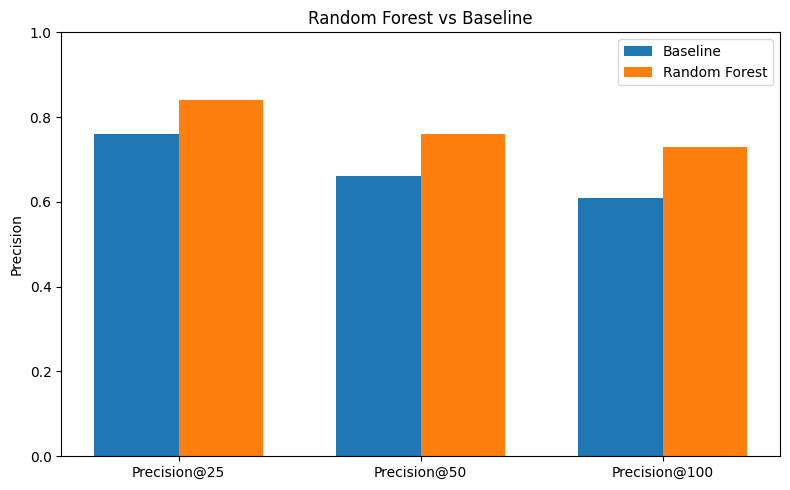

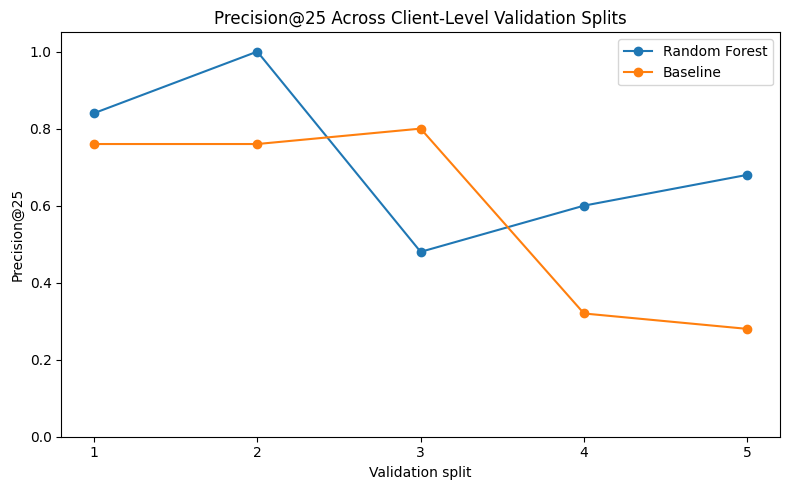

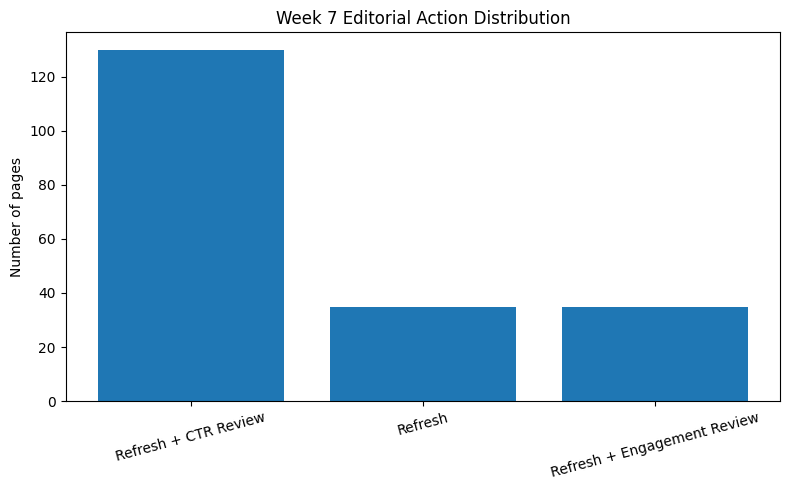

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Model vs baseline
# ---------------------------------------------------------

metrics = ["Precision@25", "Precision@50", "Precision@100"]
baseline = [0.76, 0.66, 0.61]
random_forest = [0.84, 0.76, 0.73]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, baseline, width, label="Baseline")
plt.bar(x + width/2, random_forest, width, label="Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Precision")
plt.title("Random Forest vs Baseline")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. Validation variability
# ---------------------------------------------------------

splits = [1, 2, 3, 4, 5]
rf_precision = [0.84, 1.00, 0.48, 0.60, 0.68]
baseline_precision = [0.76, 0.76, 0.80, 0.32, 0.28]

plt.figure(figsize=(8, 5))
plt.plot(splits, rf_precision, marker="o", label="Random Forest")
plt.plot(splits, baseline_precision, marker="o", label="Baseline")

plt.xlabel("Validation split")
plt.ylabel("Precision@25")
plt.title("Precision@25 Across Client-Level Validation Splits")
plt.xticks(splits)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Week 7 editorial action distribution
# ---------------------------------------------------------

actions = [
    "Refresh + CTR Review",
    "Refresh",
    "Refresh + Engagement Review"
]

counts = [130, 35, 35]

plt.figure(figsize=(8, 5))
plt.bar(actions, counts)

plt.ylabel("Number of pages")
plt.title("Week 7 Editorial Action Distribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.